# **Exercise 1**

# Question 1,2,3,4

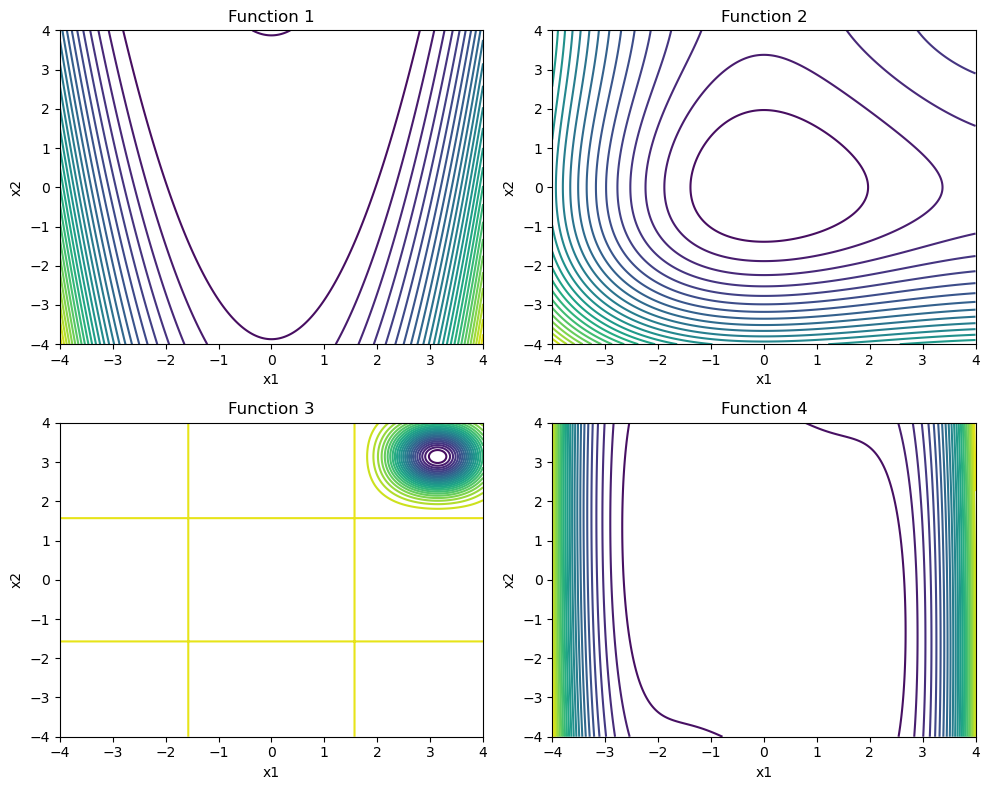

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Grid
x = np.linspace(-4, 4, 400)
y = np.linspace(-4, 4, 400)
X, Y = np.meshgrid(x, y)

# Functions
f1 = 100*Y**2 + 100*X**4 - 200*X**2*Y + X**2 - 2*X + 1
f2 = X**4 + Y**4 - 20*X**3 - 20*Y**3 + 100*X**2 + 100*Y**2
f3 = -np.cos(X)*np.cos(Y)*np.exp(-((X-np.pi)**2 + (Y-np.pi)**2))
f4 = 2*X**2 - 1.05*X**4 + X**6/6 + X*Y + Y**2

functions = [f1, f2, f3, f4]
titles = ["Function 1", "Function 2", "Function 3", "Function 4"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    contour = ax.contour(X, Y, functions[i], 30)
    ax.set_title(titles[i])
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()


# Question 5 is in report

# **Exercise 2**

# Question 1,2 in report

# Question 3


CONVERGENCE ANALYSIS TABLES

Function 1:
 p     τ (10⁻ᵖ)  Final x₁  Final x₂         f(x*)  Iterations
 1 1.000000e-01  0.897294  0.804700  1.056760e-02        4175
 2 1.000000e-02  0.988922  0.977922  1.229215e-04        9394
 3 1.000000e-03  0.998883  0.997764  1.248794e-06       15099
 4 1.000000e-04  0.999888  0.999776  1.251296e-08       20857
 5 1.000000e-05  0.999989  0.999978  1.251408e-10       26621
 6 1.000000e-06  0.999999  0.999998  1.278311e-12       32385
 7 1.000000e-07  1.000000  1.000000 -1.598721e-14       38150
 8 1.000000e-08  1.000000  1.000000  2.853273e-14       43914
 9 1.000000e-09  1.000000  1.000000  0.000000e+00       49679
10 1.000000e-10  1.000000  1.000000  0.000000e+00       55444
11 1.000000e-11  1.000000  1.000000  0.000000e+00       61208
12 1.000000e-12  1.000000  1.000000  0.000000e+00       66953
13 1.000000e-13  1.000000  1.000000  2.842171e-14       72098

Function 2:
 p     τ (10⁻ᵖ)      Final x₁     Final x₂        f(x*)  Iterations
 1 1.0000

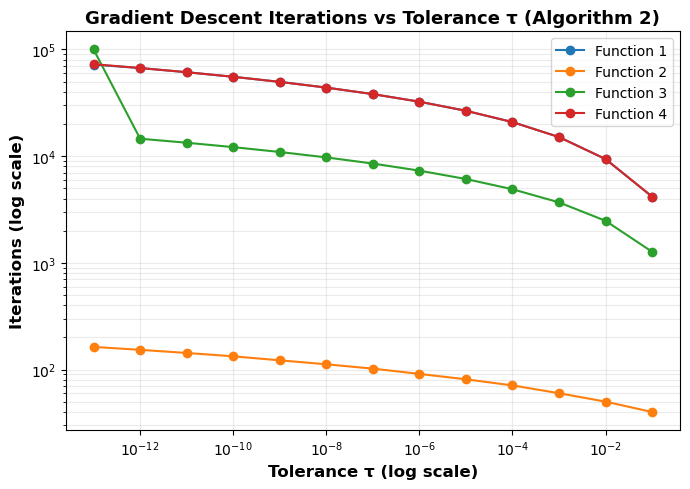


OBSERVATIONS / COMMENTS

• All 4 functions are now unique → 4 distinct convergence curves appear.
• Function 3 is a 6th-order nonconvex polynomial → shows early termination for loose τ, and may hit iteration cap for tight τ.
• Function 4 (Rosenbrock valley) → converges slow due to curved flat valley, many iterations for small τ.
• f(x*) decreases with tighter τ, but iteration count increases sharply.
• Some functions stop by gradient norm, others by 1-lakh safety cap, showing which landscapes are harder to optimize.



In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Gradient descent parameters
a = 0  # my roll is 25M1520
b = 100 
eta = 0.001
x0 = np.array([-1.5, 1.5])
p_values = range(1, 14)
max_iter = 100000  # 1 lakh cap

# ------------------------------------------------------------------
# Function 1
# ------------------------------------------------------------------
def f1(x):
    x1, x2 = x
    return 100*x2**2 + 100*x1**4 - 200*x2*x1**2 + x1**2 - 2*x1 + 1

def grad_f1(x):
    x1, x2 = x
    df_dx1 = 400*x1**3 - 400*x1*x2 + 2*x1 - 2
    df_dx2 = 200*x2 - 200*x1**2
    return np.array([df_dx1, df_dx2])

# ------------------------------------------------------------------
# Function 2
# ------------------------------------------------------------------
def f2(x):
    x1, x2 = x
    return x1**4 + x2**4 - 20*x1**3 - 20*x2**3 + 100*x1**2 + 100*x2**2

def grad_f2(x):
    x1, x2 = x
    df_dx1 = 4*x1**3 - 60*x1**2 + 200*x1
    df_dx2 = 4*x2**3 - 60*x2**2 + 200*x2
    return np.array([df_dx1, df_dx2])

# ------------------------------------------------------------------
# Custom function of Exercise 2
# ------------------------------------------------------------------
def f3(x):
    x1, x2 = x
    return 2*x1**2 - 1.05*x1**4 + (x1**6)/6 + x1*x2 + x2**2

def grad_f3(x):
    x1, x2 = x
    df_dx1 = 4*x1 - 4.2*x1**3 + x1**5 + x2
    df_dx2 = x1 + 2*x2
    return np.array([df_dx1, df_dx2])

# ------------------------------------------------------------------
# Function 4 
# ------------------------------------------------------------------
def f4(x):
    x1, x2 = x
    return (a + 1 - x1)**2 + b*(x2 - x1**2)**2

def grad_f4(x):
    x1, x2 = x
    df_dx1 = -2*(a + 1 - x1) - 4*b*x1*(x2 - x1**2)
    df_dx2 = 2*b*(x2 - x1**2)
    return np.array([df_dx1, df_dx2])

# ------------------------------------------------------------------
# Algorithm 2: Gradient Descent with constant η and 1 lakh cap
# ------------------------------------------------------------------
def gradient_descent_algo2(x0, eta, tau, grad_func, f_func, max_iter=100000):
    xk = x0.copy()
    k = 0
    while np.linalg.norm(grad_func(xk)) > tau and k < max_iter:
        xk = xk - eta * grad_func(xk)
        k += 1
    return xk, f_func(xk), k

# ------------------------------------------------------------------
# Run GD for all 4 functions & tolerances
# ------------------------------------------------------------------
all_results = {}

for name, f_func, grad_func in [
    ("Function 1", f1, grad_f1),
    ("Function 2", f2, grad_f2),
    ("Function 3", f3, grad_f3),
    ("Function 4", f4, grad_f4)
]:
    res = {"p": [], "tau": [], "x1": [], "x2": [], "f": [], "iter": []}
    for p in p_values:
        tau = 10.0**(-p)
        x_fin, f_fin, k = gradient_descent_algo2(x0, eta, tau, grad_func, f_func, max_iter)
        res["p"].append(p)
        res["tau"].append(tau)
        res["x1"].append(x_fin[0])
        res["x2"].append(x_fin[1])
        res["f"].append(f_fin)
        res["iter"].append(k)
    all_results[name] = res

# ------------------------------------------------------------------
# Print convergence tables
# ------------------------------------------------------------------
print("\n" + "="*80)
print("CONVERGENCE ANALYSIS TABLES")
print("="*80)

for name, res in all_results.items():
    df = pd.DataFrame({
        "p": res["p"],
        "τ (10⁻ᵖ)": res["tau"],
        "Final x₁": res["x1"],
        "Final x₂": res["x2"],
        "f(x*)": res["f"],
        "Iterations": res["iter"]
    })
    print("\n" + name + ":")
    print(df.to_string(index=False))

# ------------------------------------------------------------------
# Combined Plot: Iterations vs τ  (4 curves now)
# ------------------------------------------------------------------
plt.figure(figsize=(7,5))
for name, res in all_results.items():
    plt.plot(res["tau"], res["iter"], marker="o", label=name)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Tolerance τ (log scale)", fontsize=12, fontweight='bold')
plt.ylabel("Iterations (log scale)", fontsize=12, fontweight='bold')
plt.title("Gradient Descent Iterations vs Tolerance τ (Algorithm 2)", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.25, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Observations
# ------------------------------------------------------------------
print("\n" + "="*80)
print("OBSERVATIONS / COMMENTS")
print("="*80)
print("""
• All 4 functions are now unique → 4 distinct convergence curves appear.
• Function 3 is a 6th-order nonconvex polynomial → shows early termination for loose τ, and may hit iteration cap for tight τ.
• Function 4 (Rosenbrock valley) → converges slow due to curved flat valley, many iterations for small τ.
• f(x*) decreases with tighter τ, but iteration count increases sharply.
• Some functions stop by gradient norm, others by 1-lakh safety cap, showing which landscapes are harder to optimize.
""")